# Descriptive Statistics for Machine Learning — Concepts & Code

This notebook is the hands-on companion to **`Descriptive_Statistics.docx`**. Every concept explained in that document is demonstrated here with runnable Python code, using NumPy, Pandas, SciPy, and Matplotlib — the same libraries you've already met earlier in this course.

## Learning Objectives
- Compute and interpret mean, median, and mode.
- Compute range, variance, standard deviation, and IQR.
- Compute percentiles and build a boxplot.
- Measure and interpret skewness.
- Compute covariance and correlation, and visualize relationships with scatter plots.
- Standardize data using z-scores.

## Prerequisites
- Core Python, NumPy, and Pandas notebooks from earlier in this course.
- Read `Descriptive_Statistics.docx` first for the plain-English explanations behind the code below.

---
## Table of Contents
1. [Setup](#setup)
2. [Types of Data in Practice](#types)
3. [Measures of Central Tendency](#central-tendency)
4. [Measures of Dispersion](#dispersion)
5. [Percentiles, Quartiles, and Boxplots](#percentiles)
6. [Skewness](#skewness)
7. [Covariance and Correlation](#covariance-correlation)
8. [Standardization (Z-Scores)](#standardization)
9. [Practice Exercises](#practice)


<a id="setup"></a>
# 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
from scipy import stats

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


<a id="types"></a>
# 2. Types of Data in Practice

Let's build a small DataFrame that mixes the data types discussed in the document, and check how Pandas represents each.

In [2]:
data = pd.DataFrame({
    "city": ["Lahore", "Karachi", "Lahore", "Islamabad"],          # nominal (categorical, no order)
    "rating": ["Good", "Excellent", "Average", "Excellent"],        # ordinal (categorical, has order)
    "temperature_c": [22.5, 30.1, 24.0, 18.7],                      # interval (no true zero)
    "salary": [85000, 72000, 120000, 55000],                        # ratio (true zero exists)
})

print(data.dtypes)
print()
print(data)

city              object
rating            object
temperature_c    float64
salary             int64
dtype: object

        city     rating  temperature_c  salary
0     Lahore       Good           22.5   85000
1    Karachi  Excellent           30.1   72000
2     Lahore    Average           24.0  120000
3  Islamabad  Excellent           18.7   55000


Notice that Pandas only distinguishes numeric (`float64`, `int64`) from text (`object`) columns — it doesn't automatically know whether a column is nominal, ordinal, interval, or ratio. That distinction is something *you* bring to the analysis, based on what the column actually means.

<a id="central-tendency"></a>
# 3. Measures of Central Tendency

In [3]:
marks = [78, 85, 91, 67, 88]

# Using Python's built-in statistics module
print("Mean (statistics):", statistics.mean(marks))
print("Median (statistics):", statistics.median(marks))

# Using NumPy
print("Mean (NumPy):", np.mean(marks))
print("Median (NumPy):", np.median(marks))

Mean (statistics): 81.8
Median (statistics): 85
Mean (NumPy): 81.8
Median (NumPy): 85.0


In [4]:
grades = ["B", "A", "A", "C", "B", "A"]

print("Mode (statistics):", statistics.mode(grades))

# Mode with Pandas -- handles ties by returning all modes
grades_series = pd.Series(grades)
print("Mode (Pandas):", grades_series.mode().tolist())

Mode (statistics): A
Mode (Pandas): ['A']


In [5]:
# Mean, median, and mode together on a full Pandas Series
marks_series = pd.Series([78, 85, 91, 67, 88, 88])   # 88 appears twice -> it's also the mode

print("Mean:", marks_series.mean())
print("Median:", marks_series.median())
print("Mode:", marks_series.mode().tolist())

Mean: 82.83333333333333
Median: 86.5
Mode: [88]


### Visualizing How Skew Pulls the Mean Away from the Median

Let's generate a right-skewed dataset (like income data) and see the mean/median/mode relationship in Figure 1 of the companion document come to life with real numbers.

Mean income:   26,216.12
Median income: 21,675.98


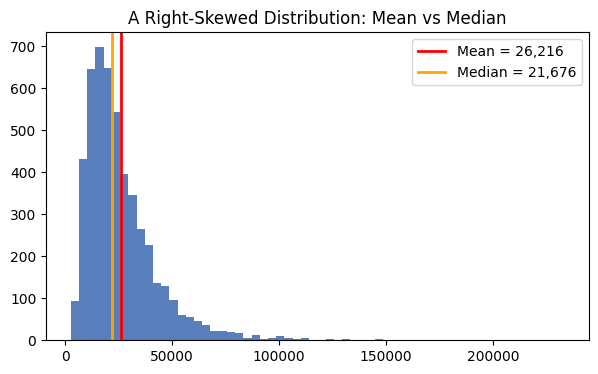

In [7]:
incomes = np.random.default_rng(1).lognormal(mean=10, sigma=0.6, size=5000)   # a classic right-skewed shape

print(f"Mean income:   {incomes.mean():,.2f}")
print(f"Median income: {np.median(incomes):,.2f}")

plt.figure(figsize=(7, 4))
plt.hist(incomes, bins=60, color="#2E5EAA", alpha=0.8)
plt.axvline(incomes.mean(), color="red", linewidth=2, label=f"Mean = {incomes.mean():,.0f}")
plt.axvline(np.median(incomes), color="orange", linewidth=2, label=f"Median = {np.median(incomes):,.0f}")
plt.title("A Right-Skewed Distribution: Mean vs Median")
plt.legend()
plt.show()

Notice the mean is noticeably higher than the median — pulled upward by a small number of very high incomes, exactly as described in the document.

<a id="dispersion"></a>
# 4. Measures of Dispersion

In [4]:
marks = [78, 85, 91, 67, 88]

data_range = max(marks) - min(marks)
print("Range:", data_range)

Range: 24


In [9]:
# Population vs sample variance/std -- ddof (delta degrees of freedom) controls this in NumPy
# ddof=0 (default) -> population formula (divide by n)
# ddof=1           -> sample formula (divide by n-1), the usual choice for real-world samples

population_variance = np.var(marks, ddof=0)
sample_variance = np.var(marks, ddof=1)

print("Population variance:", population_variance)
print("Sample variance:", sample_variance)

print("Population std dev:", np.std(marks, ddof=0))
print("Sample std dev:", np.std(marks, ddof=1))

Population variance: 73.36
Sample variance: 91.7
Population std dev: 8.565045242145542
Sample std dev: 9.57601169589929


In [9]:
# Pandas defaults to the SAMPLE formula (ddof=1) automatically -- a common source of confusion
marks_series = pd.Series(marks)
print("Pandas .var():", marks_series.var())     # sample variance by default
print("Pandas .std():", marks_series.std())      # sample std by default

Pandas .var(): 91.7
Pandas .std(): 9.57601169589929


**Common mistake:** Comparing a variance computed with NumPy's default (`ddof=0`, population formula) against one computed with Pandas' default (`ddof=1`, sample formula) and being confused why they don't match. Always check which formula a function uses by default.

In [10]:
# IQR (Interquartile Range)
q1 = np.percentile(marks, 25)
q3 = np.percentile(marks, 75)
iqr = q3 - q1

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")

Q1: 78.0, Q3: 88.0, IQR: 10.0


### Visualizing Spread

Let's recreate Figure 2 from the document: two distributions with the same mean but very different spread.

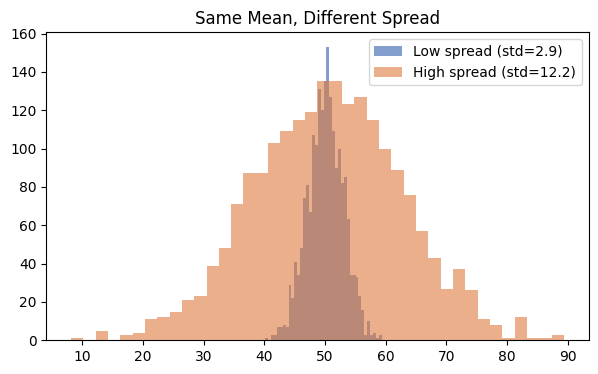

In [11]:
rng = np.random.default_rng(5)
narrow = rng.normal(loc=50, scale=3, size=2000)
wide = rng.normal(loc=50, scale=12, size=2000)

plt.figure(figsize=(7, 4))
plt.hist(narrow, bins=40, alpha=0.6, label=f"Low spread (std={narrow.std():.1f})", color="#2E5EAA")
plt.hist(wide, bins=40, alpha=0.6, label=f"High spread (std={wide.std():.1f})", color="#E07A3F")
plt.title("Same Mean, Different Spread")
plt.legend()
plt.show()

<a id="percentiles"></a>
# 5. Percentiles, Quartiles, and Boxplots

In [6]:
scores = [55, 62, 67, 70, 74, 76, 78, 80, 82, 85, 88, 90, 92, 95, 99]

for p in [10, 25, 50, 75, 90]:
    print(f"{p}th percentile: {np.percentile(scores, p)}")

10th percentile: 64.0
25th percentile: 72.0
50th percentile: 80.0
75th percentile: 89.0
90th percentile: 93.8


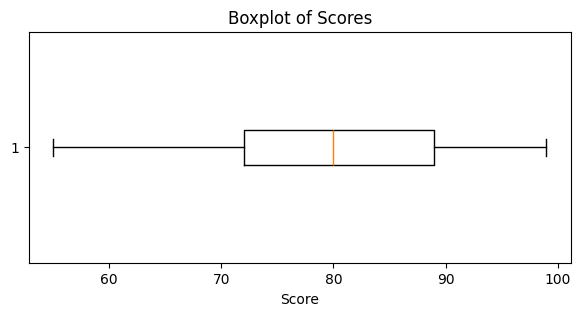

In [7]:
# A boxplot is built directly from these percentiles
plt.figure(figsize=(7, 3))
plt.boxplot(scores, vert=False)
plt.title("Boxplot of Scores")
plt.xlabel("Score")
plt.show()

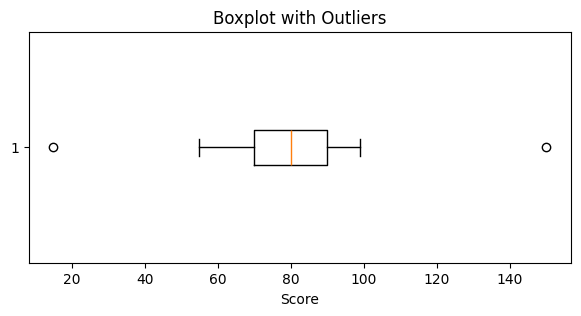

In [8]:
# Adding a couple of outliers to see them appear on the boxplot
scores_with_outliers = scores + [15, 150]

plt.figure(figsize=(7, 3))
plt.boxplot(scores_with_outliers, vert=False)
plt.title("Boxplot with Outliers")
plt.xlabel("Score")
plt.show()

<a id="skewness"></a>
# 6. Skewness

`scipy.stats.skew()` gives you a single number summarizing the direction and rough degree of skew:
- Close to 0 → roughly symmetric.
- Positive → right-skewed (long tail to the right).
- Negative → left-skewed (long tail to the left).

In [9]:
symmetric_data = np.random.default_rng(0).normal(50, 10, 5000)
right_skewed_data = np.random.default_rng(0).lognormal(3, 0.6, 5000)
left_skewed_data = 100 - np.random.default_rng(0).lognormal(3, 0.6, 5000)

print(f"Symmetric data skew:    {stats.skew(symmetric_data):.3f}")
print(f"Right-skewed data skew: {stats.skew(right_skewed_data):.3f}")
print(f"Left-skewed data skew:  {stats.skew(left_skewed_data):.3f}")

Symmetric data skew:    0.019
Right-skewed data skew: 1.848
Left-skewed data skew:  -1.848


<a id="covariance-correlation"></a>
# 7. Covariance and Correlation

In [10]:
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8])
exam_score = np.array([50, 55, 58, 65, 70, 75, 82, 88])

covariance_matrix = np.cov(hours_studied, exam_score)
print("Covariance matrix:\n", covariance_matrix)
print("Covariance between the two variables:", covariance_matrix[0, 1])

correlation_matrix = np.corrcoef(hours_studied, exam_score)
print("\nCorrelation matrix:\n", correlation_matrix)
print("Correlation coefficient:", correlation_matrix[0, 1])

Covariance matrix:
 [[  6.          32.64285714]
 [ 32.64285714 178.69642857]]
Covariance between the two variables: 32.64285714285714

Correlation matrix:
 [[1.        0.9969069]
 [0.9969069 1.       ]]
Correlation coefficient: 0.9969069020019704


In [11]:
# The same thing, using Pandas -- often more convenient with real datasets
df = pd.DataFrame({"hours_studied": hours_studied, "exam_score": exam_score})
print(df.corr())

               hours_studied  exam_score
hours_studied       1.000000    0.996907
exam_score          0.996907    1.000000


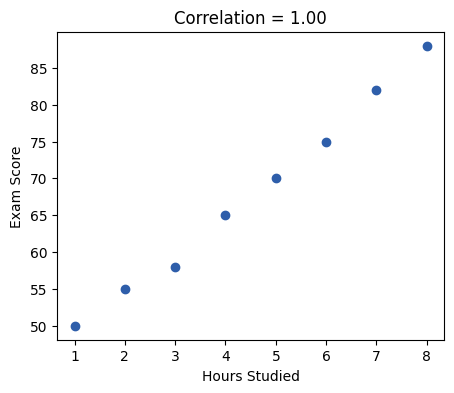

In [12]:
plt.figure(figsize=(5, 4))
plt.scatter(hours_studied, exam_score, color="#2E5EAA")
plt.title(f"Correlation = {correlation_matrix[0,1]:.2f}")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

**Common mistake:** Forgetting that `np.corrcoef()` and `df.corr()` return a full matrix (correlation of every column with every other column, including itself). For two variables, you usually just need the off-diagonal value, as shown above.

<a id="standardization"></a>
# 8. Standardization (Z-Scores)

In [13]:
salary = np.array([55000, 62000, 71000, 85000, 120000])

mean_salary = salary.mean()
std_salary = salary.std(ddof=1)

z_scores_manual = (salary - mean_salary) / std_salary
print("Manual z-scores:", z_scores_manual)

# SciPy provides a ready-made function
z_scores_scipy = stats.zscore(salary, ddof=1)
print("SciPy z-scores: ", z_scores_scipy)

Manual z-scores: [-0.91772538 -0.6455187  -0.29553868  0.24887468  1.60990808]
SciPy z-scores:  [-0.91772538 -0.6455187  -0.29553868  0.24887468  1.60990808]


In [14]:
print(f"Mean of z-scores:     {z_scores_manual.mean():.10f}  (always ~0)")
print(f"Std dev of z-scores:  {z_scores_manual.std(ddof=1):.4f}  (always ~1)")

Mean of z-scores:     -0.0000000000  (always ~0)
Std dev of z-scores:  1.0000  (always ~1)


### ML Connection Recap
Standardized features (mean 0, standard deviation 1) are exactly what algorithms like K-Nearest Neighbors, Support Vector Machines, and neural networks expect — without this step, a large-scale feature like `salary` could completely dominate a small-scale feature like `age` purely due to differences in units, not real importance.

<a id="practice"></a>
# Practice Exercises

Attempt each exercise before checking the solution.

## Level 1 — Basic
1. Given `values = [12, 15, 12, 18, 20, 12, 25]`, compute the mean, median, and mode using either `statistics` or NumPy/Pandas.
2. Given the same `values`, compute the range, the sample variance, and the sample standard deviation.
3. Compute the 25th, 50th, and 75th percentiles of `values`.

## Level 2 — Applied
4. Generate 1000 samples from `np.random.default_rng(2).exponential(scale=2.0, size=1000)` (a right-skewed distribution). Compute its mean, median, and skewness, and plot a histogram with both the mean and median marked as vertical lines.
5. Given `X = [10, 20, 30, 40, 50]` and `Y = [12, 18, 33, 38, 55]`, compute the correlation coefficient between them and create a scatter plot.
6. Standardize the array `heights = np.array([150, 160, 165, 170, 180, 190])` into z-scores, and confirm the resulting mean is (approximately) 0 and standard deviation is (approximately) 1.

## Level 3 — ML-oriented Challenge
7. You're given two features from a dataset: `feature_a = np.random.default_rng(3).normal(50, 5, 200)` and `feature_b = np.random.default_rng(3).normal(500, 300, 200)`. Standardize BOTH features, then confirm that after standardization, their standard deviations are equal (even though their original scales were very different).
8. Create a small DataFrame representing 6 products with columns `name` and `price`. Compute the IQR of `price`, and use it to flag any product whose price falls outside `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR` as a potential outlier (this is the exact rule boxplots use).

### Solutions

In [ ]:
#1st Problem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
values = [12, 15, 12, 18, 20, 12, 25]
print("The mean is ",statistics.mean(values))
print("Them median is ", statistics.median(values))


In [ ]:
#2nd Problem
range = max(values)-min(values)
print(range)
print("The sample variance is ", np.var(values, ddof=1))
print("The sample Standard Deviation is ", np.std(values, ddof=1))


In [ ]:
#3rd Problem
for p in [25,50,75] :
    print(f"the {p}th Percentile : {np.percentile(values,p)}")

In [ ]:
#4th Problem
import numpy as np
import matplotlib.pyplot as plt

sample = np.random.default_rng(2).exponential(scale=2.0, size=1000)
mean = np.mean(sample)
median = np.median(sample)
plt.figure(figsize=(7, 4))
plt.hist(sample, bins=10, color="#2E5EAA", alpha=0.8)
plt.axvline(mean, color="red", linewidth=2,
            label=f"Mean: {mean:.2f}")
plt.axvline(median, color="yellow", linewidth=2,
            label=f"Median: {median:.2f}")
plt.title("Right Skewness of Sample")
plt.legend()
plt.show()


In [ ]:
#5th Problem
X = [10, 20, 30, 40, 50]
Y = [12, 18, 33, 38, 55]
correlation = np.corrcoef(X,Y)
print("The Correlation between x and y is ", correlation)
plt.figure(figsize=(5,3))
plt.scatter(X,Y, color = "blue")
plt.title("Correlation")
plt.xlabel("Days")
plt.ylabel("Income in Thousands")
plt.show()

In [40]:
#6th Problem
heights = np.array([150, 160, 165, 170, 180, 190])
heights_std = np.std(heights , ddof = 1)
z = (heights - heights.mean()) / heights_std
print(z)
print("Mean of Z ",z.mean())
print("Std of Z ", z.std(ddof =1))

[-1.34138724 -0.64153303 -0.29160592  0.05832118  0.7581754   1.45802961]
Mean of Z  7.031412489292658e-16
Std of Z  1.0


In [44]:
#7th Problem
feature_a = np.random.default_rng(3).normal(50, 5, 200)
feature_b = np.random.default_rng(3).normal(500, 300, 200)
z1 = (feature_a - feature_a.mean()) / feature_a.std(ddof=1)
z2 = (feature_b - feature_b.mean()) / feature_b.std(ddof=1)
print("Std of feature a ", z1.std(ddof=1))
print("Std of feature b ", z2.std(ddof=1))

print("Original Std feature a ", feature_a.std(ddof=1))
print("Original Std feature b ", feature_b.std(ddof=1))


Std of feature a  1.0
Std of feature b  0.9999999999999999
Original Std feature a  5.163392910183042
Original Std feature b  309.80357461098254


In [57]:
#8th Problem
import pandas as pd
small_df = pd.DataFrame({
    "name" : ["laptop","mobile","charger","cable","cover"],
    "price" : [340,340,2300000,150,200]
})
print(small_df.head())

Q1 = small_df["price"].quantile(0.25)
Q3 = small_df["price"].quantile(0.75)
IQR = Q3-Q1
print("Inter Quartile Range",IQR)

lower_outlier = Q1 - 1.5*IQR
higher_outlier = Q3 + 1.5*IQR

print("Lower Outlier ",lower_outlier)
print("Higher Outlier ",higher_outlier)
small_df["is_outlier"] = (small_df["price"] < lower_outlier) | (small_df["price"] > higher_outlier)
print(small_df)

      name    price
0   laptop      340
1   mobile      340
2  charger  2300000
3    cable      150
4    cover      200
Inter Quartile Range 140.0
Lower Outlier  -10.0
Higher Outlier  550.0
      name    price  is_outlier
0   laptop      340       False
1   mobile      340       False
2  charger  2300000        True
3    cable      150       False
4    cover      200       False


---
**Well done!** You've now implemented, in code, every descriptive statistics concept from the companion document. Next, move on to `Inferential_Statistics.docx` and its companion notebook, `Inferential_Statistics_Concepts_and_Code.ipynb`, to learn how to go from describing a sample to drawing conclusions about a whole population.